# Подготовка данных к машинному обучению
### План занятия

Сегодня мы разберем полный путь подготовки данных перед обучением модели.


На практике именно подготовка данных занимает большую часть времени специалиста по анализу данных и машинному обучению. Хорошо обученная модель не сможет компенсировать плохо подготовленный набор данных.


На лекции мы научимся:

* понимать разницу между "чистыми" данными и данными, готовыми для машинного обучения;

* анализировать распределения признаков;

* выбирать способы преобразования числовых признаков;

* правильно задавать типы данных;

* кодировать категориальные признаки;

* масштабировать признаки;

* собирать итоговый machine-ready dataset.

Используемые библиотеки:

Pandas

NumPy

Matplotlib

Seaborn

Scikit-learn

**Цель лекции**: Научиться правильно готовить данные для машинного обучения, чтобы избежать распространенных ошибок и улучшить качество моделей.

## Почему cleaned dataset ≠ machine-ready dataset?

Очень распространённая ошибка начинающих аналитиков — считать, что после удаления пропусков и дубликатов данные уже готовы для обучения модели.

На самом деле это только первый этап.

Cleaned dataset - это такой датасет, в котором удалены дубликаты, исправлены ошибки, обработаны пропуски, удалены некорректные данные, приведены все названия столбцов к единому формату.

|age|city|salary|
|--|----|-------|
|25|Moscow|80000|
|31|Kazan|95000|

Такой датасеь уже приятно читать человеку, но для машинного обучения всё ещё недостаточно

## Что такое Machine-ready dataset?

Модель ожидает данные в определённом виде.

Например:
|age|city_Moscow|city_Kazan|salary_log|
|--|----|-------|------|
|25|1|0|11.29|
|31|0|1|11.46|

В такого рода датасете уже нет текстовых категорий, признаки имеют корректные типы, распределения подготовлены, значения промасштабированы (если это необходимо) и данные сразу можно передавать модели

### Основные этапы:
Практически любой ML проект проходит похожие этапы:
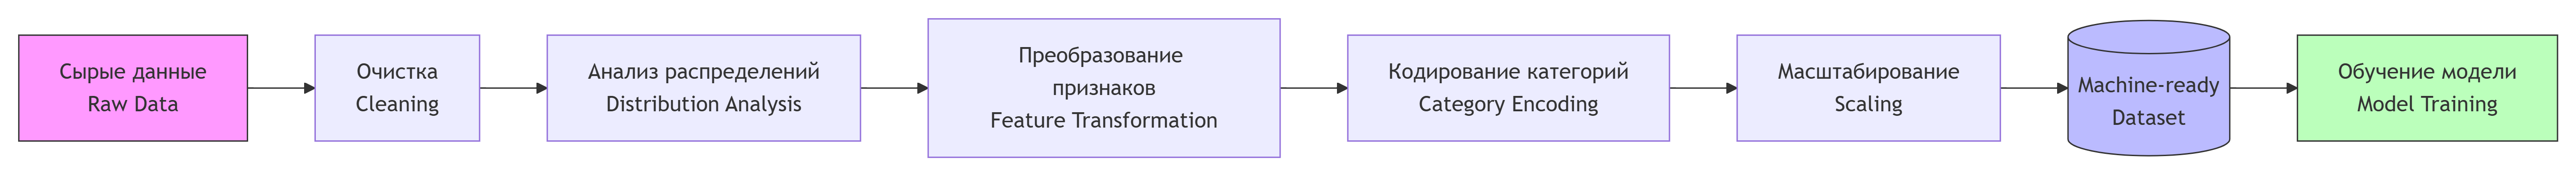

Используем сегодня библиотеки:


In [3]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    RobustScaler,
    OneHotEncoder
)


In [4]:
df = pd.read_csv("CustomerPurchaseDataset.csv")

### Посмотрим структуру данных

Обычно первым делом мы проверяем:

количество строк;

количество столбцов;

тип каждого признака;

наличие пропусков.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   country             5000 non-null   object 
 1   device_type         5000 non-null   object 
 2   education           5000 non-null   object 
 3   membership          5000 non-null   object 
 4   gender              5000 non-null   object 
 5   is_returning        5000 non-null   int64  
 6   has_newsletter      5000 non-null   int64  
 7   age                 5000 non-null   int64  
 8   session_duration    5000 non-null   float64
 9   satisfaction_score  5000 non-null   float64
 10  pages_visited       5000 non-null   int64  
 11  cart_items          5000 non-null   int64  
 12  discount_used       5000 non-null   float64
 13  total_spent         5000 non-null   float64
 14  purchase_made       5000 non-null   int64  
dtypes: float64(4), int64(6), object(5)
memory usage: 586.1+

### Теория распределений

Любой числовой признак имеет распределение.

Оно показывает, как значения встречаются в данных.

Например:

* возраст;
* зарплата;
* площадь квартиры;
* стоимость автомобиля.

От формы распределения зависит выбор методов анализа и подготовки данных.

### Основные характеристики распределения

In [6]:
df.describe()

,is_returning,has_newsletter,age,session_duration,satisfaction_score,pages_visited,cart_items,discount_used,total_spent,purchase_made
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,0.641600,0.404200,38.647800,19.558940,3.836266,5.981000,2.952200,14.811840,1964.888606,0.485600
std,0.479578,0.490786,13.618489,41.730242,0.698622,2.412593,8.194177,8.595992,7360.810678,0.499843
min,0.000000,0.000000,18.000000,0.800000,-0.927685,1.000000,0.000000,0.000000,47.770000,0.000000
25%,0.000000,0.000000,30.000000,7.000000,3.400000,4.000000,1.000000,7.400000,597.140000,0.000000
50%,1.000000,0.000000,38.000000,12.100000,3.900000,6.000000,2.000000,14.700000,1099.630000,0.000000
75%,1.000000,1.000000,46.000000,20.925000,4.400000,7.000000,4.000000,22.200000,1963.012500,1.000000
max,1.000000,1.000000,149.000000,593.764631,5.000000,21.000000,196.000000,30.000000,198342.202196,1.000000


Посмотрите на статистику

Здесь есть настоящие выбросы

```
median total_spent = 1100
max total_spent = 198342
```
То есть максимальная сумма почти в 180 раз больше медианы

Как вы думаете, это ошибка данных или VIP-клиент?

`max(age)=149`

Может ли покупатель иметь возраст 149 лет?




Разберём самые важные

### **Среднее (Mean)**

Среднее арифметическое:

${\bar{x} = \frac{x_{1} + x_{2}+...+x_{n}}{n}}$


Используется очень часто.

Но **сильно чувствительно к большим выбросам**.

Например:

50

55

58

60

1000


Среднее уже плохо описывает "типичное" значение.

### **Медиана**

Медиана — **центральное значение после сортировки**.

Она гораздо устойчивее к выбросам.

Именно поэтому при анализе доходов обычно смотрят именно медиану.

### **Квантили**

25%

50%

75%

Именно они образуют основу для:

boxplot;

межквартильного размаха;

поиска выбросов.


## **Формы распределений**

Можно выделить несколько наиболее распространённых форм.

### Симметричное распределение

Среднее примерно равно медиане

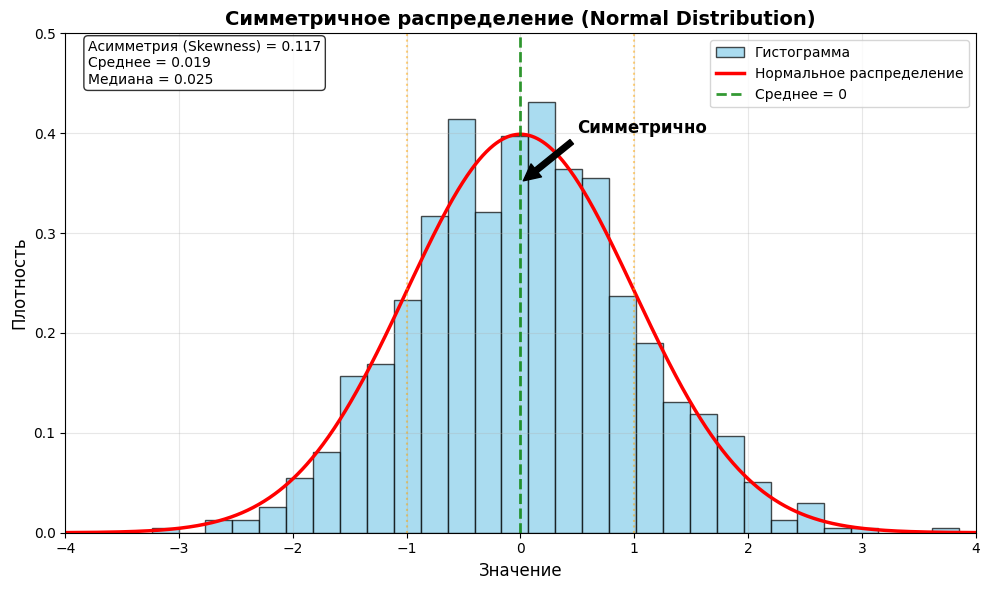

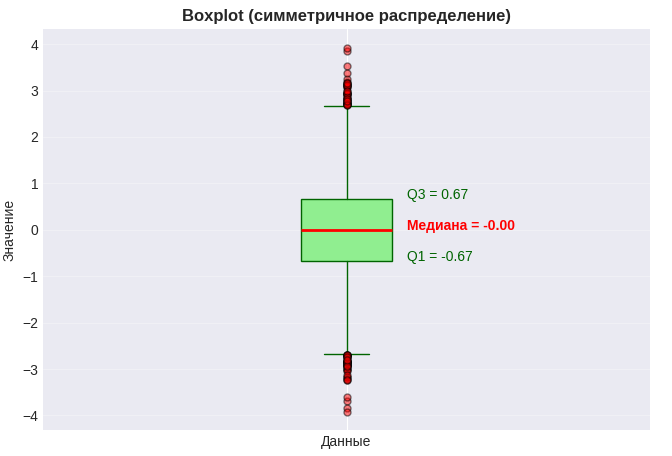

### Правосторонняя асимметрия
Большинство объектов имеют небольшие значения.

Небольшое число объектов имеет очень большие значения.

**Так распределены:**

* зарплаты;

* стоимость квартир;

* доход компаний;

* количество подписчиков.


**Среднее становится больше медианы**

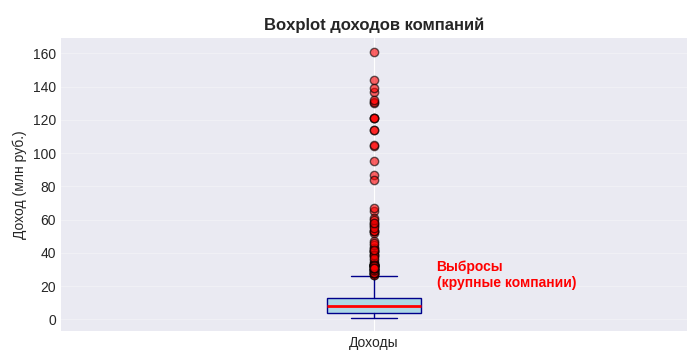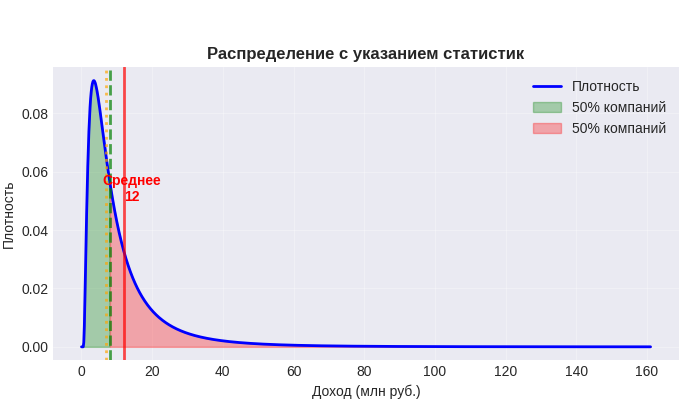

### Левосторонняя асимметрия

Большинство наблюдений имеют большие значения.

Небольшое количество объектов имеет маленькие значения.

**Например:**

* результаты очень простого экзамена;

* процент заряда аккумуляторов корпоративных устройств вечером после зарядки;

* заполненность складов после поставки;

* время выполнения задач.

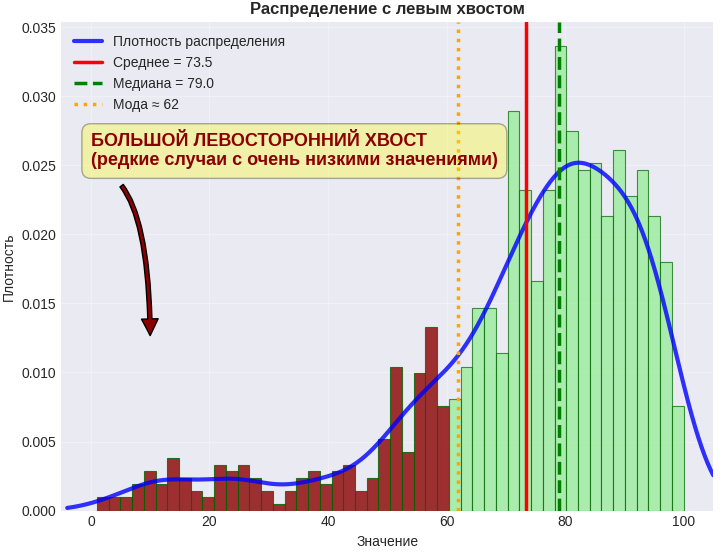

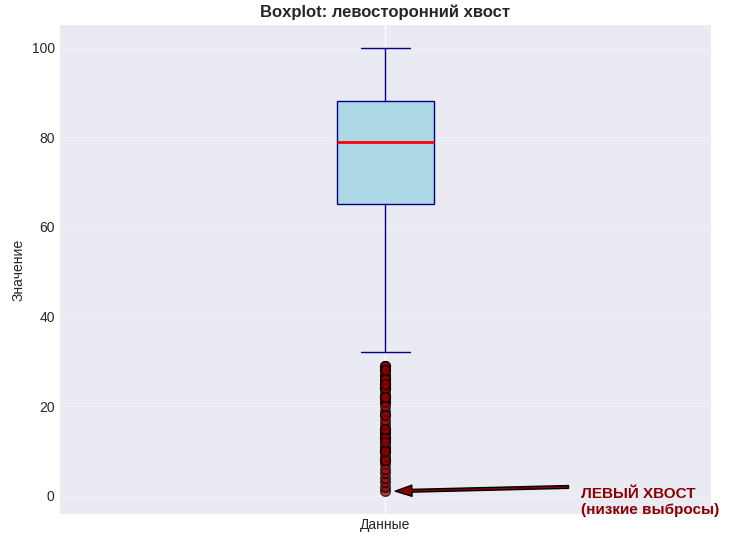

**Среднее становится меньше медианы**

### Почему распределение важно?

Практически все дальнейшие преобразования зависят именно от него.

Например:
|Распределение|Что обычно делают с данными|
|-------------|---------------------------|
|Нормальное|Оставляют как есть|
|Сильно скошенное| Логарифмируют|
Есть выбросы|RobustScaler|
Большой разброс|Масштабируют|

Теперь, когда мы понимаем:

какие бывают распределения;

почему среднее иногда вводит в заблуждение;

чем отличается cleaned dataset от machine-ready dataset,


можно перейти к практической части и посмотреть всё это на реальных данных.

## Демонстрация на данных

In [7]:
df.head()

,country,device_type,education,membership,gender,is_returning,has_newsletter,age,session_duration,satisfaction_score,pages_visited,cart_items,discount_used,total_spent,purchase_made
0,UK,Desktop,Bachelor,Silver,F,0,1,33,10.2,3.5,5,4,16.2,5875.90,0
1,Canada,Mobile,Bachelor,Gold,M,0,0,39,7.0,3.0,8,2,7.9,1566.68,1
2,Brazil,Tablet,High School,Silver,M,1,1,29,13.1,3.6,8,2,28.3,1141.96,0
3,France,Desktop,Bachelor,Bronze,F,1,0,41,4.6,2.9,4,0,20.9,1392.40,0
4,USA,Tablet,Bachelor,Bronze,F,1,0,28,50.7,3.9,8,1,29.3,1301.10,1


Проверим размер датасета

In [8]:
print("Количество строк", df.shape[0])
print("Количество столбцов", df.shape[1])

Количество строк 5000
Количество столбцов 15


Посмотрим основные статистики

In [9]:
df['total_spent'].describe()

count      5000.000000
mean       1964.888606
std        7360.810678
min          47.770000
25%         597.140000
50%        1099.630000
75%        1963.012500
max      198342.202196
Name: total_spent, dtype: float64

### Среднее и медиана

In [10]:
mean_salary = df["total_spent"].mean()
median_salary = df["total_spent"].median()

print(f"Средняя зарплата : {mean_salary:,.0f}")
print(f"Медианная зарплата: {median_salary:,.0f}")

Средняя зарплата : 1,965
Медианная зарплата: 1,100


### Построим гистограмму

Самый простой способ посмотреть распределение — гистограмма.

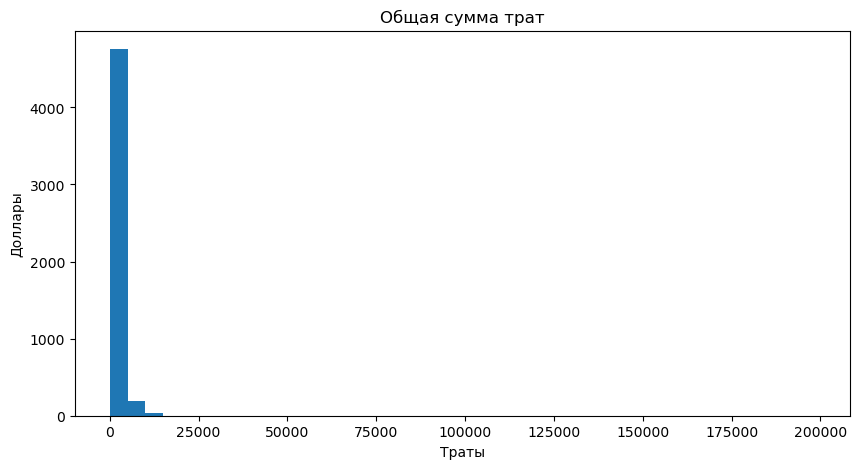

In [11]:
plt.figure(figsize=(10,5))

plt.hist(df["total_spent"], bins=40)

plt.title("Общая сумма трат")
plt.xlabel("Траты")
plt.ylabel("Доллары")

plt.show()

### Что мы видим?

Большинство наблюдений находится слева.

Справа располагается длинный "хвост".

Это классический пример правосторонней асимметрии.

Такая форма встречается очень часто:


(зарплаты;
стоимость недвижимости;
доходы компаний;
число просмотров видео;
количество подписчиков)

Практически все подобные признаки требуют дополнительной подготовки перед обучением модели.

### Добавим линии среднего и медианы

Чтобы различие было нагляднее, нанесем их на график.

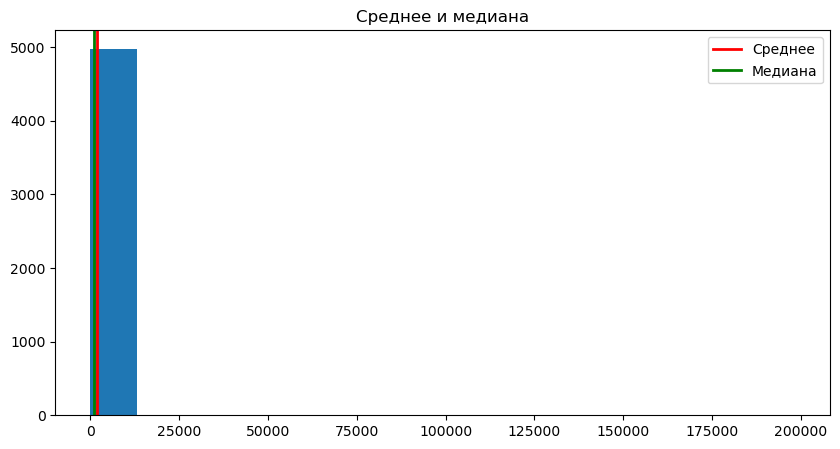

In [12]:
plt.figure(figsize=(10,5))

plt.hist(df["total_spent"], bins=15)

plt.axvline(mean_salary,
            color="red",
            linewidth=2,
            label="Среднее")

plt.axvline(median_salary,
            color="green",
            linewidth=2,
            label="Медиана")

plt.legend()

plt.title("Среднее и медиана")

plt.show()

### Boxplot

Другой популярный способ анализа распределения — диаграмма размаха (boxplot).

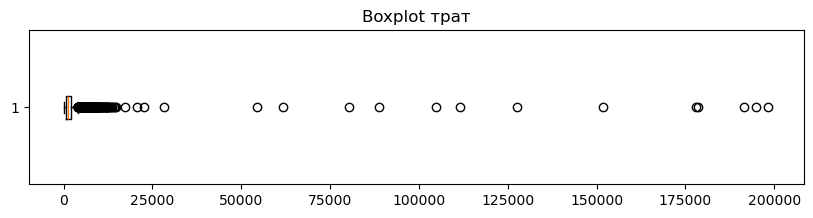

In [13]:
plt.figure(figsize=(10,2))

plt.boxplot(
    df["total_spent"],
    vert=False
)

plt.title("Boxplot трат")

plt.show()

На этой диаграмме отображаются:

медиана;

первый квартиль;

третий квартиль;

диапазон типичных значений;

потенциальные выбросы.

В отличие от гистограммы, boxplot занимает мало места и позволяет быстро сравнивать несколько признаков.

### Межквартильный размах (IQR)

Основой boxplot является **межквартильный** размах.

Он вычисляется как

IQR = Q3 ​− Q1​

где
Q1 — 25-й процентиль,
Q3 — 75-й процентиль.

Посчитаем его вручную.

In [14]:
Q1 = df["total_spent"].quantile(0.25)
Q3 = df["total_spent"].quantile(0.75)

IQR = Q3 - Q1

print("Q1 - ", Q1)
print("Q3 - ", Q3)
print("IQR - ", IQR)

Q1 -  597.14
Q3 -  1963.0124999999998
IQR -  1365.8725


IQR показывает диапазон, внутри которого находится центральная половина наблюдений.

Именно этот показатель часто используют для поиска выбросов

## Поиск выбросов по правилу 1.5 × IQR

Классическое правило выглядит следующим образом:

нижняя граница = Q1 − 1.5 × IQR

верхняя граница = Q3 + 1.5 × IQR

Рассчитаем эти значения.

In [15]:
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(lower)
print(upper)

-1451.6687500000003
4011.82125


Теперь можно найти все потенциальные выбросы

In [16]:
outliers = df[
    (df["total_spent"] < lower) |
    (df["total_spent"] > upper)
]

print(outliers.shape)

(397, 15)


Важно подчеркнуть

**Выброс — это не обязательно ошибка.**

Например, генеральный директор компании действительно может получать значительно больше большинства сотрудников. Такие значения могут быть полностью корректными и не должны автоматически удаляться.

### Почему такие распределения неудобны?

Предположим, что мы хотим обучить модель.

Очень длинный правый хвост создает несколько проблем:

* большие значения начинают доминировать;

* масштаб признака становится слишком широким;

* некоторые алгоритмы обучаются хуже;

* сложнее интерпретировать результаты.


Поэтому часто выполняют преобразование признаков.

Самое популярное — **логарифмирование**

### Логарифмическое преобразование

В NumPy используется функция
`np.log()`

Построим новый признак и помотрим первые строки:





In [17]:
df["total_spent_log"] = np.log(df["total_spent"])

df[["total_spent", "total_spent_log"]].head()

,total_spent,total_spent_log
0,5875.90,8.678615
1,1566.68,7.356714
2,1141.96,7.040501
3,1392.40,7.238784
4,1301.10,7.170965


Мы увидим, что диапазон значений значительно уменьшился

### Сравним распределения

до


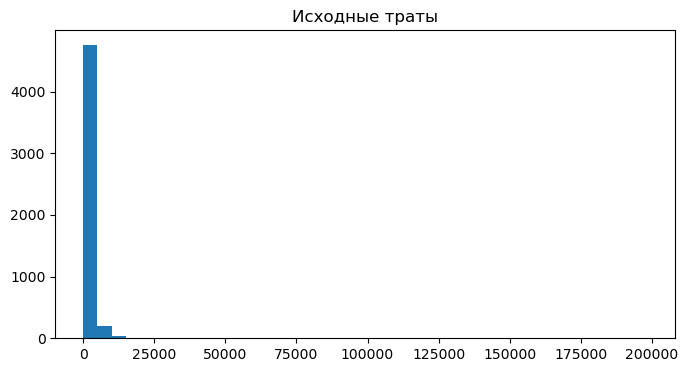

In [18]:
plt.figure(figsize=(8,4))

plt.hist(df["total_spent"], bins=40)

plt.title("Исходные траты")

plt.show()

После логарифмирования

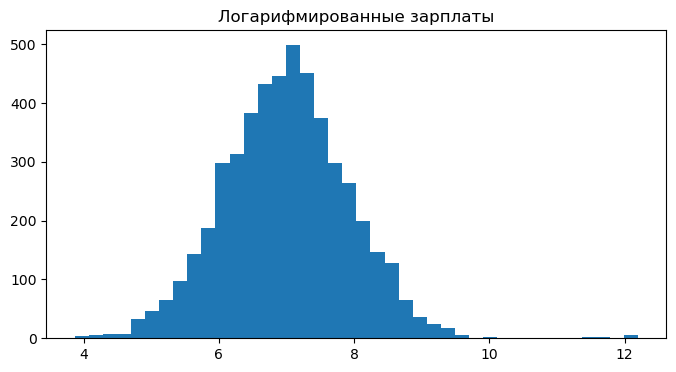

In [19]:
plt.figure(figsize=(8,4))

plt.hist(df["total_spent_log"], bins=40)

plt.title("Логарифмированные зарплаты")

plt.show()

Теперь распределение стало значительно более симметричным

Именно этого эффекта мы и добиваемся

### Почему логарифм работает?

Логарифм не изменяет порядок объектов.

Если одна зарплата была больше другой, то после логарифмирования это также останется верным.

Однако большие значения "сжимаются" значительно сильнее, чем маленькие.

Например

| Зарплата | ln(зарплата) |
| -------: | -----------: |
|   30 000 |        10.31 |
|   60 000 |        11.00 |
|  120 000 |        11.70 |
|  600 000 |        13.30 |


Из таблицы видно, что разница между исходными значениями огромна, тогда как после логарифмирования она становится гораздо меньше. Благодаря этому распределение становится ближе к симметричному, а многие алгоритмы машинного обучения работают устойчивее.

### Преобразование признаков

До этого момента мы использовали логарифмирование как инструмент для уменьшения асимметрии распределения.

Однако на практике существует несколько способов логарифмического преобразования, и выбор зависит от свойств данных.

Важно понимать не только **как** выполнить преобразование, но и **когда** его применять.

# Часть 2. Кодирование категориальных признаков

Почему нужно кодировать категории?
Большинство алгоритмов ML работают только с числами, такие как:

* Линейная регрессия
* Нейронные сети
* Метод опорных векторов

### Зачем вообще преобразовывать признаки?

В машинном обучении признаки редко бывают «идеальными».

Например, в одном датасете могут одновременно встречаться:

```
возраст — от 18 до 65;

зарплата — от 30 000 до 800 000;

количество покупок — от 0 до 5;

число просмотров страницы — от 1 до нескольких миллионов.
```


Такие признаки имеют разные масштабы и разные формы распределения.

Некоторые алгоритмы чувствительны к этому (линейная регрессия,логистическая регрессия,
метод k-ближайших соседей,
SVM,
нейронные сети).


Поэтому перед обучением модели признаки часто преобразуют.

### Какие бывают преобразования?

Наиболее распространённые способы:

|Преобразование|Когда используют|
|--------------|----------------|
|Логарифм|Правосторонняя асимметрия|
|Квадратный корень|Умеренная асимметрия|
|Степенное преобразование|Сложные распределения|
|Масштабирование|Разные диапазоны признаков|
|Стандартизация|Для большинства ML-моделей|

Сегодня будем рассматривать именно логарифмическое преобразование

### Натуральный логарифм

Самый простой вариант:

`y=ln(x)`

В Python используется функция
`np.log(x)`

In [20]:
numbers = np.array([10, 100, 1000])

np.log(numbers)

array([2.30258509, 4.60517019, 6.90775528])

Каждое увеличение значения в несколько раз приводит лишь к небольшому увеличению логарифма


### Ограничение логарифма

Логарифм определён только **для положительных чисел**.

Например, `np.log(-5)` или `np.log(0)` не дадут корректного результата.

Поэтому перед логарифмированием всегда необходимо проверить данные


#### Проверим минимальное значение

In [21]:
df["total_spent"].min()

47.77

Или более универсально

In [22]:
numeric_columns = df.select_dtypes(include="number").columns # Выбор тольько тех колонок, которые числовые

df[numeric_columns].min()

is_returning           0.000000
has_newsletter         0.000000
age                   18.000000
session_duration       0.800000
satisfaction_score    -0.927685
pages_visited          1.000000
cart_items             0.000000
discount_used          0.000000
total_spent           47.770000
purchase_made          0.000000
total_spent_log        3.866398
dtype: float64

Если минимальное значение больше нуля, можно использовать обычный логарифм

### Что делать, если есть нули?

Это встречается очень часто.

Например:

* количество покупок
* число обращений
* количество жалоб
* число публикаций
* стаж работы

Во всех этих случаях значение 0 вполне допустимо.

Обычный логарифм использовать уже нельзя

### Преобразование ln(x + 1)

Самый популярный вариант:

y=ln(x+1)

В Python:

`np.log1p(x)`

или

`np.log(x + 1)`

Но предпочтительнее использовать именно `log1p`

### Почему лучше log1p?

Функция

`np.log1p(x)`

специально разработана для вычисления

`ln(1+x)`

Она обладает двумя преимуществами
(корректно работает при нуле,
обеспечивает более высокую численную точность для маленьких значений)

Поэтому в большинстве проектов используют именно её.

In [23]:
values = df['cart_items']

print(pd.DataFrame({
    "value" : values,
    "log1p" : np.log1p(values)
}))

      value     log1p
0         4  1.609438
1         2  1.098612
2         2  1.098612
3         0  0.000000
4         1  0.693147
...     ...       ...
4995      3  1.386294
4996      2  1.098612
4997      3  1.386294
4998      2  1.098612
4999      0  0.000000

[5000 rows x 2 columns]


Теперь даже нулевые значения преобразуются корректно


### Что делать, если есть отрицательные значения?

Например,

температура,

финансовый результат,

изменение курса,

разница между показателями.


В этих случаях обычное логарифмирование использовать нельзя.

Один из вариантов — выполнить сдвиг


### Логарифмирование со сдвигом

Пусть минимальное значение равно


In [24]:
df['satisfaction_score'].min()

-0.9276847063762876

Тогда можно вычислить величину сдвига

In [25]:
shift = abs(df["satisfaction_score"].min()) + 1

После этого преобразуем признак

In [26]:
df["satisfaction_score_log"] = np.log(
    df["satisfaction_score"] + shift
)

df[['satisfaction_score', 'satisfaction_score_log']]

,satisfaction_score,satisfaction_score_log
0,3.5,1.691513
1,3.0,1.594869
2,3.6,1.709769
3,2.9,1.574367
4,3.9,1.762620
...,...,...
4995,3.5,1.691513
4996,3.8,1.745311
4997,4.4,1.844934
4998,4.9,1.920986


In [27]:
df['satisfaction_score'].min()

-0.9276847063762876

In [28]:
df['satisfaction_score_log'].min()

0.0

### Когда логарифмировать не нужно?

Очень распространённая ошибка — **логарифмировать все числовые признаки подряд**

Это делать нельзя.

Например,

возраст

```
18

22

30

45

60
```

имеет вполне естественное распределение

После преобразования будет:

```
2.89

3.09

3.40

3.81

4.09
```
Мы не получим никакой практической пользы

### **Признаки, которые обычно логарифмируют**

Чаще всего преобразуют:

* доход
* цену
* зарплату
* количество просмотров
* число клиентов
* число заказов
* площадь объектов
* население городов

Общее свойство таких признаков — они имеют длинный правый хвост

### **Признаки, которые обычно НЕ логарифмируют**

Как правило, без необходимости не преобразуют:

* возраст
* рейтинг
* оценки
* процент выполнения
* температуру
* вероятность
* бинарные признаки
* One-Hot признаки

Для таких переменных логарифм либо ничего не улучшает, либо делает интерпретацию сложнее

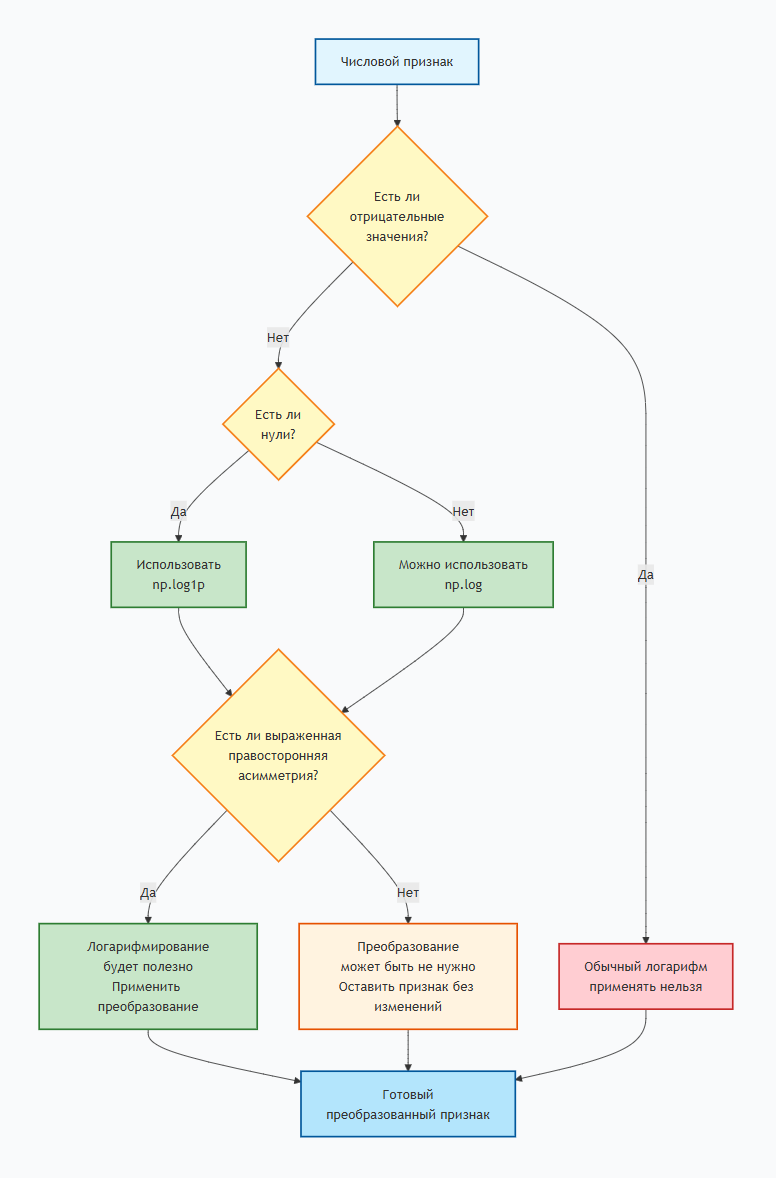

Однако большинство реальных датасетов содержат не только числа, но и текстовые категории: города, профессии, отделы, типы товаров, уровни образования и другие признаки. Прежде чем передать такие данные модели машинного обучения, необходимо правильно определить тип каждого столбца и преобразовать категориальные значения в числовую форму.

Именно этим мы займёмся

## Изучаем структуру датасета

Перед любыми преобразованиями необходимо понять, какие данные содержатся в каждом столбце.

Начнем с просмотра информации о датасете.

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   country                 5000 non-null   object 
 1   device_type             5000 non-null   object 
 2   education               5000 non-null   object 
 3   membership              5000 non-null   object 
 4   gender                  5000 non-null   object 
 5   is_returning            5000 non-null   int64  
 6   has_newsletter          5000 non-null   int64  
 7   age                     5000 non-null   int64  
 8   session_duration        5000 non-null   float64
 9   satisfaction_score      5000 non-null   float64
 10  pages_visited           5000 non-null   int64  
 11  cart_items              5000 non-null   int64  
 12  discount_used           5000 non-null   float64
 13  total_spent             5000 non-null   float64
 14  purchase_made           5000 non-null   

Например, мы можем получить следующий результат:

```
country                 object
device_type             object
is_returning            int64
session_duration        float64

```



Уже отсюда видно:

`страна` — категориальный;

`тип устройства` — категориальный;

`на пенсии` — числовой (0, 1) (да, нет);

`длительность сессии` — числовой (число с запятой).

Именно от типа признака зависит дальнейшая обработка.

### Какие типы данных встречаются в Pandas?

На практике чаще всего используются несколько основных типов.

|Тип	|Назначение|	Пример|
|-----|----------|--------|
|int64|	целые числа|	возраст|
|float64|	вещественные числа|	зарплата|
|object|	текст|	город|
|bool|	логические значения|	True / False|
|datetime64|	дата и время|	дата заказа|
|category|	категориальные признаки|	уровень образования|

Обратите внимание, что `object` — это не категориальный тип данных. Это универсальный тип для хранения текстовой информации.

### Почему важно исправлять типы?

Представим ситуацию.

Возраст случайно сохранился как текст.

In [30]:
df["age"].head()

0    33
1    39
2    29
3    41
4    28
Name: age, dtype: int64

Выглядит правильно.

Но проверим тип

In [31]:
df["age"].dtype

dtype('int64')

А могло быть:
```
df["age"].dtype
object
```



Для человека разницы почти нет

Для алгоритма — принципиальная

### Преобразование типов

В Pandas используется функция `astype()`

Например,


In [32]:
df["is_returning"] = df["is_returning"].astype(bool)
df["has_newsletter"] = df["has_newsletter"].astype(bool)
df["gender"] = df["gender"].astype(bool)


In [33]:
df.info() # проверяем структуру

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   country                 5000 non-null   object 
 1   device_type             5000 non-null   object 
 2   education               5000 non-null   object 
 3   membership              5000 non-null   object 
 4   gender                  5000 non-null   bool   
 5   is_returning            5000 non-null   bool   
 6   has_newsletter          5000 non-null   bool   
 7   age                     5000 non-null   int64  
 8   session_duration        5000 non-null   float64
 9   satisfaction_score      5000 non-null   float64
 10  pages_visited           5000 non-null   int64  
 11  cart_items              5000 non-null   int64  
 12  discount_used           5000 non-null   float64
 13  total_spent             5000 non-null   float64
 14  purchase_made           5000 non-null   

## Работа с датами

Если столбец содержит даты, его также необходимо привести к специальному типу.

Например,

`df["hire_date"] = pd.to_datetime(df["hire_date"])`

После этого становятся доступны операции:

`df["hire_date"].dt.year`

`df["hire_date"].dt.month`

`df["hire_date"].dt.dayofweek`



### Найдем категориальные признаки

Вместо того чтобы перечислять столбцы вручную, можно автоматически найти текстовые признаки

In [34]:
categorical_columns = df.select_dtypes(
    include=["object", "category"]
).columns

categorical_columns

Index(['country', 'device_type', 'education', 'membership'], dtype='object')

Это особенно удобно, когда в датасете десятки или сотни столбцов

### Аналогично найдем числовые признаки

In [35]:
numeric_columns = df.select_dtypes(
    include="number"
).columns

numeric_columns

Index(['age', 'session_duration', 'satisfaction_score', 'pages_visited',
       'cart_items', 'discount_used', 'total_spent', 'purchase_made',
       'total_spent_log', 'satisfaction_score_log'],
      dtype='object')

## Почему модели не понимают текст?

Предположим, что имеется столбец

country

USA

UK

Germany

France...


Для человека всё очевидно.

Однако модель работает только с числами.

Можно ли просто заменить города числами?

USA → 1

UK → 2

Germany → 3

**Нет**

Алгоритм может решить, что

3 > 2 > 1

то есть Германия "больше" США.

Такой зависимости не существует.

### One-Hot Encoding

Поэтому используется другой подход.

Каждая категория становится отдельным столбцом.

Исходные данные

country

USA

UK

Germany

France...

После преобразования
| country_USA | country_UK |
| ----------- | ----------- |
| 1           | 0           |
| 0           | 1           |
| 1           | 0           |

Такое представление уже корректно воспринимается алгоритмами



Выполним One-Hot Encoding в Pandas

Самый простой способ — `pd.get_dummies()`

Например,

In [36]:
encoded = pd.get_dummies(
    df,
    columns=["country"]
)

encoded.head()

,device_type,education,membership,gender,is_returning,has_newsletter,age,session_duration,satisfaction_score,pages_visited,...,country_Australia,country_Brazil,country_Canada,country_France,country_Germany,country_India,country_Japan,country_Spain,country_UK,country_USA
0,Desktop,Bachelor,Silver,True,False,True,33,10.2,3.5,5,...,False,False,False,False,False,False,False,False,True,False
1,Mobile,Bachelor,Gold,True,False,False,39,7.0,3.0,8,...,False,False,True,False,False,False,False,False,False,False
2,Tablet,High School,Silver,True,True,True,29,13.1,3.6,8,...,False,True,False,False,False,False,False,False,False,False
3,Desktop,Bachelor,Bronze,True,True,False,41,4.6,2.9,4,...,False,False,False,True,False,False,False,False,False,False
4,Tablet,Bachelor,Bronze,True,True,False,28,50.7,3.9,8,...,False,False,False,False,False,False,False,False,False,True


Теперь вместо одного текстового столбца появятся несколько бинарных признаков

### OneHotEncoder из Scikit-learn

В реальных проектах чаще используется именно он.

In [37]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    sparse_output=False,
    handle_unknown="ignore"
)

encoded = encoder.fit_transform(
    df[["country"]]
)


# Полученная матрица содержит только закодированные категории
encoded

array([[0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(5000, 10))

In [38]:
encoder.get_feature_names_out() # названия новых признаков

array(['country_Australia', 'country_Brazil', 'country_Canada',
       'country_France', 'country_Germany', 'country_India',
       'country_Japan', 'country_Spain', 'country_UK', 'country_USA'],
      dtype=object)

Соберем DataFrame обратно

In [39]:
encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(),
    index=df.index
)

encoded_df.head()

,country_Australia,country_Brazil,country_Canada,country_France,country_Germany,country_India,country_Japan,country_Spain,country_UK,country_USA
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


Теперь можно объединить его с исходными числовыми признаками

In [40]:
df_ready = pd.concat(
    [
        df.drop(columns=["country"]),
        encoded_df
    ],
    axis=1
)

df_ready.head()

,device_type,education,membership,gender,is_returning,has_newsletter,age,session_duration,satisfaction_score,pages_visited,...,country_Australia,country_Brazil,country_Canada,country_France,country_Germany,country_India,country_Japan,country_Spain,country_UK,country_USA
0,Desktop,Bachelor,Silver,True,False,True,33,10.2,3.5,5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,Mobile,Bachelor,Gold,True,False,False,39,7.0,3.0,8,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Tablet,High School,Silver,True,True,True,29,13.1,3.6,8,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Desktop,Bachelor,Bronze,True,True,False,41,4.6,2.9,4,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Tablet,Bachelor,Bronze,True,True,False,28,50.7,3.9,8,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


Преимущества:
* не создает исскуственный порядок
* Подходит для номинальных признаков

Недостатки:
* Curse of dimensionality (Проклятие размерности)
* Для большого числа категорий создает много признаков

Когда применять:

1. Когда категории номинальные (между ними нет никакой связи и порядка): цвета, марки машин, типы занятости.

2. Когда вы используете линейные модели, логистическую регрессию, SVM или нейросети.

3. Когда количество уникальных категорий невелико (обычно меньше 10–15).

### Label Encoding (Метка)
Простое преобразование в числа:

In [41]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['education_encoded'] = le.fit_transform(df['education'])

print(le.classes_)  # ['Бакалавр', 'Магистр', 'PhD', nan]
print(df['education_encoded'])  # [0, 1, 2, 0, 3, 1]

['Bachelor' 'High School' 'Master' 'PhD']
0       0
1       0
2       1
3       0
4       0
       ..
4995    2
4996    1
4997    1
4998    2
4999    1
Name: education_encoded, Length: 5000, dtype: int64


Проблемы, которые возникают:
* Создается искусственный порядок (PhD > Магистр > Бакалавр)
* Не подходит для номинальных признаков (тип данных, которые используются только для маркировки или классификации объектов без использования числового значения или порядка)

Когда применять:
1. Когда у категорий есть естественный порядок или важность (Ordinal variables). Например: грейды сотрудников, уровни образования, тарифные планы.
2. Для кодирования зависимой переменной (целевого признака / y), если это задача классификации.
3. В древесных моделях (Random Forest, XGBoost), если порядок категорий не принципиален, но уникальных значений слишком много для One-Hot.

# Frequency Encoding (Частотное кодирование)

In [42]:
frequency = df['education'].value_counts() / len(df)
df['education_freq'] = df['education'].map(frequency)

df

,country,device_type,education,membership,gender,is_returning,has_newsletter,age,session_duration,satisfaction_score,pages_visited,cart_items,discount_used,total_spent,purchase_made,total_spent_log,satisfaction_score_log,education_encoded,education_freq
0,UK,Desktop,Bachelor,Silver,True,False,True,33,10.2,3.5,5,4,16.2,5875.90,0,8.678615,1.691513,0,0.3466
1,Canada,Mobile,Bachelor,Gold,True,False,False,39,7.0,3.0,8,2,7.9,1566.68,1,7.356714,1.594869,0,0.3466
2,Brazil,Tablet,High School,Silver,True,True,True,29,13.1,3.6,8,2,28.3,1141.96,0,7.040501,1.709769,1,0.3006
3,France,Desktop,Bachelor,Bronze,True,True,False,41,4.6,2.9,4,0,20.9,1392.40,0,7.238784,1.574367,0,0.3466
4,USA,Tablet,Bachelor,Bronze,True,True,False,28,50.7,3.9,8,1,29.3,1301.10,1,7.170965,1.762620,0,0.3466
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,Australia,Tablet,Master,Gold,True,True,False,41,12.0,3.5,6,3,23.9,344.17,1,5.841136,1.691513,2,0.2510
4996,USA,Tablet,High School,Bronze,True,True,False,46,10.4,3.8,1,2,15.1,655.34,1,6.485154,1.745311,1,0.3006
4997,UK,Tablet,High School,Bronze,True,False,False,29,19.3,4.4,6,3,5.5,1362.82,0,7.217311,1.844934,1,0.3006
4998,India,Desktop,Master,Silver,True,True,True,71,5.0,4.9,12,2,25.9,535.12,1,6.282491,1.920986,2,0.2510


**Пример:** Если в выборке из 100 человек 60 живут в Москве, 30 в Питере и 10 в Казани, то признак города заменится на числа: Москва - 0.6, Питер - 0.3, Казань - 0.1.

**Когда применять**:
1. Когда у вас высокоразмерный признак (High Cardinality) — сотни или тысячи уникальных значений (например, модели телефонов, ZIP-коды, ID категорий товаров).

2. Для древесных моделей (деревья решений отлично умеют делать сплиты по таким частотным признакам).

3. Когда сама частота появления категории имеет скрытый смысл (например, редкие категории могут часто коррелировать с мошенничеством или поломками).


**В чем опасность**: Если две совершенно разные категории (например, города Самара и Красноярск) встречаются в данных ровно одинаковое количество раз, они получат одинаковый код (например, 0.04). Модель больше не сможет их отличить друг от друга.

### Алгоритм принятия решения:
1. Есть ли в категориях логический порядок?

Да - Используйте Label Encoding (точнее, его разновидность OrdinalEncoder из sklearn, чтобы вручную задать правильный порядок вроде 0, 1, 2).

Нет - Переходите к шагу 2.

2. Сколько уникальных значений у признака?

Мало (до 10–15) - Используйте One-Hot Encoding.

Много (десятки, сотни, тысячи) - Используйте Frequency Encoding (или более продвинутый Target Encoding, который кодирует через связь с целевой переменной).

## Зачем нужно масштабирование?

Даже после кодирования признаки имеют совершенно разные диапазоны.

Например,

| Признак  | Диапазон       |
| -------- | -------------- |
| Возраст  | 18–65          |
| Опыт     | 0–40           |
| Зарплата | 30 000–800 000 |

Алгоритмы, основанные на расстояниях или градиентном спуске, чувствительны к таким различиям.

Поэтому признаки часто масштабируют


### StandardScaler

Наиболее распространённый вариант.

Он делает так, чтобы каждый признак имел:

```среднее около 0;```

```стандартное отклонение около 1.```

In [43]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled = scaler.fit_transform(
    df_ready[numeric_columns]
)

In [44]:
scaled

array([[-0.41475708, -0.22429478, -0.4813752 , ..., -0.97160303,
         1.79669665, -0.34468085],
       [ 0.02586449, -0.30098545, -1.19714134, ...,  1.02922693,
         0.38179407, -0.9997194 ],
       [-0.7085048 , -0.15479387, -0.33822197, ..., -0.97160303,
         0.04333434, -0.22094098],
       ...,
       [-0.7085048 , -0.0062057 ,  0.80700385, ..., -0.97160303,
         0.23258377,  0.69519514],
       [ 2.37584619, -0.34891711,  1.52276999, ...,  1.02922693,
        -0.76800569,  1.21066208],
       [ 0.53992298, -0.31296837,  0.80700385, ...,  1.02922693,
        -0.64232727,  0.69519514]], shape=(5000, 10))

Когда применять: Когда большинство алгоритмов машинного обучения требуют, чтобы признаки имели одинаковый масштаб (например, в линейной регрессии, логистической регрессии, SVM, методе главных компонент (PCA) и K-Means).

Ограничение: Если в данных есть экстремальные выбросы, они сильно сместят среднее значение, и масштабирование остальных данных станет неэффективным.

### MinMaxScaler

Этот способ переводит значения в диапазон

`0 ... 1`

In [45]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaled = scaler.fit_transform(
    df_ready[numeric_columns]
)

Когда применять:В нейронных сетях (они любят фиксированные диапазоны, особенно на входе и в скрытых слоях с функциями активации вроде Sigmoid или Tanh).

В алгоритмах, использующих расстояния, где важно сохранить разреженность данных (много нулей), например, в рекомендательных системах (разреженные матрицы).

При работе с изображениями (пиксели от 0 до 255 переходят в 0–1).


Ограничение: Если у вас есть хотя бы одно гигантское значение-выброс, оно станет единицей, а все нормальные значения сгруппируются где-то между 0.001 и 0.01.

### RobustScaler

Если в данных много выбросов, предыдущие методы могут работать плохо.

В этом случае применяют `RobustScaler`.

`Он использует медиану и межквартильный размах вместо среднего и стандартного отклонения.`

In [46]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

scaled = scaler.fit_transform(
    df_ready[numeric_columns]
)

Именно поэтому мы подробно изучали медиану и IQR в начале занятия

Когда применять: Когда в ваших данных присутствует много шума и сильных выбросов, которые вы не можете или не хотите удалять (например, редкие, но реальные финансовые транзакции на огромные суммы).

Как это работает: Медиана и IQR не вычисляются по экстремальным значениям, поэтому масштаб "нормальной" части данных останется идеальным, а выбросы просто уйдут далеко вправо или влево, не ломая общую картину.

## Сравним результаты масштабирования

Построим небольшую таблицу

In [47]:
comparison = pd.DataFrame({
    "Исходный": df_ready["total_spent"],
    "Standard": StandardScaler().fit_transform(df_ready[["total_spent"]]).flatten(),
    "MinMax": MinMaxScaler().fit_transform(df_ready[["total_spent"]]).flatten(),
    "Robust": RobustScaler().fit_transform(df_ready[["total_spent"]]).flatten()
})

comparison.head(10)

,Исходный,Standard,MinMax,Robust
0,5875.90,0.531382,0.029391,3.496864
1,1566.68,-0.054104,0.007660,0.341943
2,1141.96,-0.111810,0.005518,0.030991
3,1392.40,-0.077783,0.006781,0.214347
4,1301.10,-0.090188,0.006321,0.147503
5,523.34,-0.195861,0.002398,-0.421921
6,589.58,-0.186861,0.002732,-0.373424
7,235.63,-0.234951,0.000947,-0.632563
8,816.73,-0.155998,0.003878,-0.207120
9,645.29,-0.179291,0.003013,-0.332637


Обратите внимание, что все три метода меняют масштаб данных, но сохраняют порядок объектов.

Выбор конкретного метода зависит от задачи и свойств данных

|Метод|Когда применять?|Как реагирует на выбросы?|Что делает с распределением?|
|-----|----------------|-------------------------|----------------------------|
|StandardScaler|Данные уже примерно нормальны; алгоритм чувствителен к дисперсии (линейные модели, SVM, K-Means).|Плохо (выбросы искажают среднее и дисперсию).|Сохраняет форму, меняет масштаб.
|MinMaxScaler|Нужно жестко ограничить диапазон (от 0 до 1); важно сохранить нулевые значения; для нейросетей или изображений.|Очень плохо (выбросы «схлопнут» основные данные в крошечный отрезок).|Сохраняет форму, меняет масштаб.|
|RobustScaler|В данных много сильных выбросов, которые нельзя удалять.|Отлично (выбросы не влияют на масштаб полезных данных).|Сохраняет форму, меняет масштаб.|
|Логарифмирование|Данные сильно скошены вправо (длинный «хвост» больших значений: доходы, цены, просмотры).|Трансформирует их (сближает гигантские значения).|Меняет форму на более нормальную|

### Алгоритм принятия решения в проекте:

1. Посмотрите на график распределения признака (гистограмму).
2. Если распределение имеет огромный хвост справа — сначала примените логарифмирование.

3. Оцените выбросы. Если они есть и их много — используйте RobustScaler.
4. Если распределение похоже на колокол (нормальное) и выбросов почти нет — используйте StandardScaler.
5. Если вы строите нейросеть или вам нужен строгий диапазон [0, 1] — используйте MinMaxScaler.

## Сохраняем итоговый CSV
Обычно после подготовки данные сохраняют

In [48]:
df.to_csv(

    "machine_ready_dataset.csv",

    index=False

)